In [1]:
import os
import multiprocessing

import pickle

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import pandas as pd

import torch
import torch.nn.functional as F

import random




def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything(1)


blue = '#0073B7'
yellow = '#FFD23F'
gray = '#7A7A7A'
purple = '#B05AA3'
green = '#00A651'
orange = '#F7941D'


blue_yellow = LinearSegmentedColormap.from_list(
    "blue_yellow", ["#0073B7", "#FFD23F"]
)


gray = '#C0C0C0'
purple = '#B05AA3'

gray_purple = LinearSegmentedColormap.from_list(
    "gray_purple",
    [gray , purple]
)


blue_distribution = '#00AEEF'
red_distribution = '#F15A2A'


os.environ["OMP_NUM_THREADS"]="1"
os.environ["MKL_NUM_THREADS"]="1"
os.environ["OPENBLAS_NUM_THREADS"]="1"
os.environ["NUMEXPR_NUM_THREADS"]="1"
os.environ["MKL_DYNAMIC"]="FALSE"
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
multiprocessing.set_start_method("fork")

In [2]:
from src.model import SSCNetwork
from src.utils.general import make_input, LatentSpace, get_ordered_indices, test_network, get_cos_sim_torch, get_sample_from_num_swaps
from src.utils.plotting import compare_distributions_12

from network_parameters import network_parameters

from Figure_4_utils import higher_order_selectivity

In [3]:
recording_parameters = {}
recording_parameters["regions"] = ["mtl_sensory", "mtl_semantic", "mtl", "ctx"]
recording_parameters["rate_activity"] = np.inf
recording_parameters["connections"] = ["ctx_mtl"]
recording_parameters["rate_connectivity"] = np.inf

input_params = {}
input_params["num_days"] = 1
input_params["day_length"] = 80
input_params["mean_duration"] = 5
input_params["fixed_duration"] = True
input_params["num_swaps"] = 2


latent_specs = {}
latent_specs["num"] = 2
latent_specs["total_sizes"] = [50, 50]
latent_specs["act_sizes"] = [10, 10]
latent_specs["dims"] = [5, 5]
latent_specs["prob_list"] = [0.5/5 if i==j else 0.5/20 for i in range(5) for j in range(5)]

In [4]:
initial_network_path = "checkpoints/network_3_B.pt"

In [5]:
network = higher_order_selectivity('intact', 2, recording_parameters, input_params, latent_specs, initial_network_path, get_network=True)

0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050


In [6]:
network.init_recordings(recording_parameters)
torch.save(network, "checkpoints/network_5.pt")
network = torch.load("checkpoints/network_5.pt", weights_only=False)

In [7]:
network.frozen = False
network.activity_recordings_rate = 1
network.connectivity_recordings_rate = 1

input_params["num_days"] = 1
input_params["latent_space"] = LatentSpace(**latent_specs)

input, input_episodes, input_latents, network = test_network(network, input_params, sleep=True, print_rate=50)

0


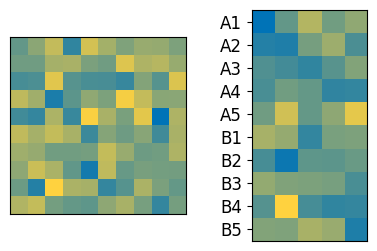

In [8]:
h_random = torch.randn(network.mtl_size)
mtl = h_random





fig, ax = plt.subplots(1, 2, figsize=(5, 3))
ax[0].imshow(mtl[:100].reshape((-1, 10)), cmap=blue_yellow)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].imshow(mtl[100:][network.ordered_indices_mtl_semantic[:50]].reshape((-1, 5)), cmap=blue_yellow)


# Example parameters
N = 10  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B

# Positions for labels (centered in each segment)
positions = [M * i for i in range(NA + NB)]
ax[1].set_yticks(positions, labels, fontsize=12)

plt.savefig('Figures_SVG/6b1.svg', dpi=300, transparent=True)

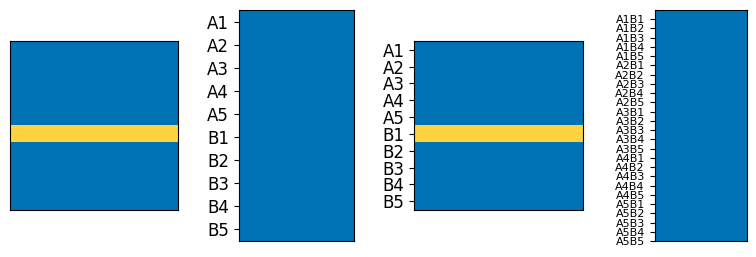

In [9]:
semantic_charge = 1
mtl_sparsity = (semantic_charge/network.max_semantic_charge_input)*network.mtl_sparsity.clone()
mtl = network.pattern_complete('mtl', h_0=h_random, sparsity=mtl_sparsity)


ctx_hat = F.linear(mtl, network.ctx_mtl) + network.ctx_b*network.ctx_IM
ctx, _ = network.activation(ctx_hat, 'ctx', sleep=True, subregion_index=0)



fig, ax = plt.subplots(1, 4, figsize=(10, 3))
ax[0].imshow(mtl[:100].reshape((-1, 10)), cmap=blue_yellow)
ax[1].imshow(mtl[100:][network.ordered_indices_mtl_semantic[:50]].reshape((-1, 5)), cmap=blue_yellow)
ax[2].imshow(ctx[network.ordered_indices_ctx][:100].reshape((-1, 10)), cmap=blue_yellow)
ax[3].imshow(ctx[network.ordered_indices_ctx_episodes[:250]].reshape((-1, 10)), cmap=blue_yellow)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[2].set_xticks([])
ax[3].set_xticks([])


# Example parameters
N = 10  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B
# Positions for labels (centered in each segment)
positions = [M * i for i in range(NA + NB)]


ax[1].set_yticks(positions, labels, fontsize=12)

# Example parameters
N = 10  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B
# Positions for labels (centered in each segment)
positions = [M * i for i in range(NA + NB)]

ax[2].set_yticks(positions, labels, fontsize=12)




# Example parameters
N = 25  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA * NB)  # Size of each group (equal-sized segments for each AiBj)

# Generate combination labels
labels_episodes = [f"A{i+1}B{j+1}" for i in range(NA) for j in range(NB)]

# Positions for labels (centered in each segment)
positions_episodes = [M * (k + 0.5) for k in range(NA * NB)]


ax[3].set_yticks(positions_episodes, labels_episodes, fontsize=8)

plt.savefig('Figures_SVG/6b2.svg', dpi=300, transparent=True)

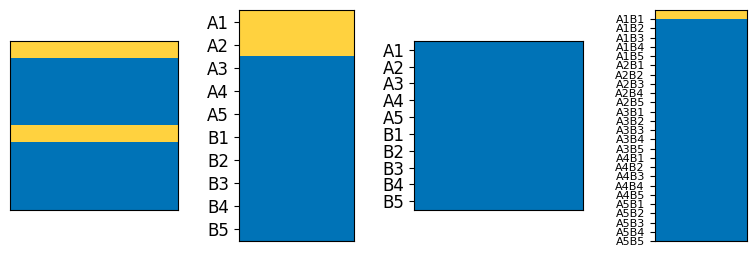

In [10]:
semantic_charge = 2
mtl_sparsity = (semantic_charge/network.max_semantic_charge_input)*network.mtl_sparsity.clone()
mtl = network.pattern_complete('mtl', h_0=h_random, sparsity=mtl_sparsity)


ctx_hat = F.linear(mtl, network.ctx_mtl) + network.ctx_b*network.ctx_IM
ctx, _ = network.activation(ctx_hat, 'ctx', sleep=True, subregion_index=1)



fig, ax = plt.subplots(1, 4, figsize=(10, 3))
ax[0].imshow(mtl[:100].reshape((-1, 10)), cmap=blue_yellow)
ax[1].imshow(mtl[100:][network.ordered_indices_mtl_semantic[:50]].reshape((-1, 5)), cmap=blue_yellow)
ax[2].imshow(ctx[:100].reshape((-1, 10)), cmap=blue_yellow)
ax[3].imshow(ctx[network.ordered_indices_ctx_episodes][:250].reshape((-1, 10)), cmap=blue_yellow)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[2].set_xticks([])
ax[3].set_xticks([])

# Example parameters
N = 10  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B
# Positions for labels (centered in each segment)
positions = [M * i for i in range(NA + NB)]


ax[1].set_yticks(positions, labels, fontsize=12)


# Example parameters
N = 10  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B
# Positions for labels (centered in each segment)
positions = [M * i for i in range(NA + NB)]

ax[2].set_yticks(positions, labels, fontsize=12)

# Example parameters
N = 25  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA * NB)  # Size of each group (equal-sized segments for each AiBj)

# Generate combination labels
labels_episodes = [f"A{i+1}B{j+1}" for i in range(NA) for j in range(NB)]

# Positions for labels (centered in each segment)
positions_episodes = [M * (k + 0.5) for k in range(NA * NB)]


ax[3].set_yticks(positions_episodes, labels_episodes, fontsize=8)


plt.savefig('Figures_SVG/6b3.svg', dpi=300, transparent=True)

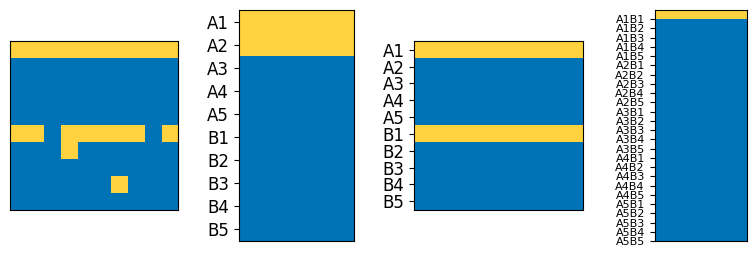

In [11]:
mtl = torch.stack(network.activity_recordings["mtl"], axis=0)[network.awake_indices][-1]
ctx = torch.stack(network.activity_recordings["ctx"], axis=0)[network.awake_indices][-1]


fig, ax = plt.subplots(1, 4, figsize=(10, 3))
ax[0].imshow(mtl[:100].reshape((-1, 10)), cmap=blue_yellow)
ax[1].imshow(mtl[100:][network.ordered_indices_mtl_semantic[:50]].reshape((-1, 5)), cmap=blue_yellow)
ax[2].imshow(ctx[network.ordered_indices_ctx][:100].reshape((-1, 10)), cmap=blue_yellow)
ax[3].imshow(ctx[network.ordered_indices_ctx_episodes][:250].reshape((-1, 10)), cmap=blue_yellow)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[2].set_xticks([])
ax[3].set_xticks([])

# Example parameters
N = 10  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B
# Positions for labels (centered in each segment)
positions = [M * i for i in range(NA + NB)]


ax[1].set_yticks(positions, labels, fontsize=12)


# Example parameters
N = 10  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B
# Positions for labels (centered in each segment)
positions = [M * i for i in range(NA + NB)]

ax[2].set_yticks(positions, labels, fontsize=12)

# Example parameters
N = 25  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA * NB)  # Size of each group (equal-sized segments for each AiBj)

# Generate combination labels
labels_episodes = [f"A{i+1}B{j+1}" for i in range(NA) for j in range(NB)]

# Positions for labels (centered in each segment)
positions_episodes = [M * (k + 0.5) for k in range(NA * NB)]


ax[3].set_yticks(positions_episodes, labels_episodes, fontsize=8)


plt.savefig('Figures_SVG/6c.svg', dpi=300, transparent=True)

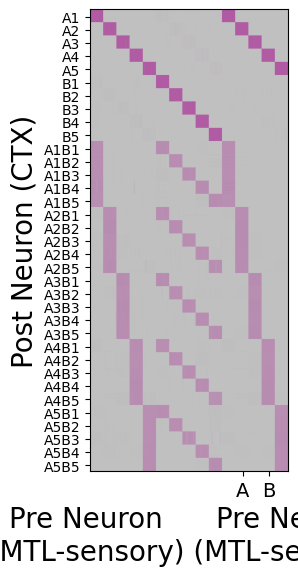

In [12]:
full_ordered_indices_ctx = torch.cat([
    network.ordered_indices_ctx[:100],
    network.ordered_indices_ctx_episodes[:250]
])


# Compute the full indexing array
full_ordered_indices = torch.cat([
    torch.arange(100),
    network.mtl_sensory_size + network.ordered_indices_mtl_semantic
])


fig = plt.figure(figsize=(5, 6))

plt.imshow(network.ctx_mtl[full_ordered_indices_ctx][:, full_ordered_indices[:150]], cmap=gray_purple)


# Example parameters
N = 100  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B

# Positions for labels (centered in each segment)
positions = [M * (i + 0.5) for i in range(NA + NB)]


# Example parameters
N = 250  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA * NB)  # Size of each group (equal-sized segments for each AiBj)

# Generate combination labels
labels_episodes = [f"A{i+1}B{j+1}" for i in range(NA) for j in range(NB)]

# Positions for labels (centered in each segment)
positions_episodes = [100 + M * (k + 0.5) for k in range(NA * NB)]

positions.extend(positions_episodes)
labels.extend(labels_episodes)

plt.yticks(positions, labels)

plt.xticks([115, 135], ["A", "B"],  fontsize=14)
plt.xlabel("Pre Neuron      Pre Neuron\n  (MTL-sensory) (MTL-semantic)", fontsize=20)
plt.ylabel("Post Neuron (CTX)", fontsize=20)
plt.savefig('Figures_SVG/6d.svg', dpi=300, transparent=True)


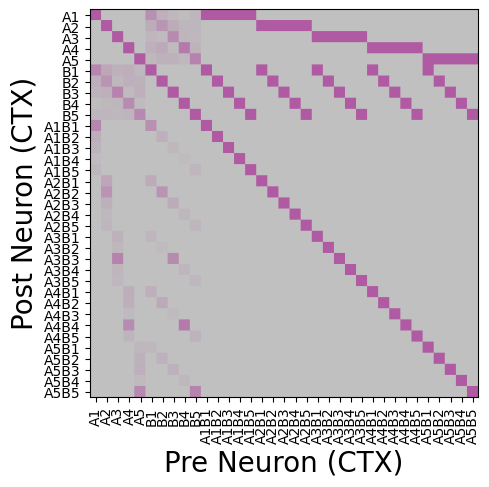

In [13]:

fig = plt.figure(figsize=(5, 6))


plt.imshow(network.ctx_ctx[full_ordered_indices_ctx][:, full_ordered_indices_ctx], cmap=gray_purple)


# Example parameters
N = 100  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA + NB)  # Size of each group (equal-sized labels)

# Generate labels
labels_A = [f"A{i+1}" for i in range(NA)]
labels_B = [f"B{i+1}" for i in range(NB)]
labels = labels_A + labels_B

# Positions for labels (centered in each segment)
positions = [M * (i + 0.5) for i in range(NA + NB)]


# Example parameters
N = 250  # Total number of y-axis ticks (from 0 to N)
NA = 5   # Number of A groups
NB = 5   # Number of B groups
M = N // (NA * NB)  # Size of each group (equal-sized segments for each AiBj)

# Generate combination labels
labels_episodes = [f"A{i+1}B{j+1}" for i in range(NA) for j in range(NB)]

# Positions for labels (centered in each segment)
positions_episodes = [100 + M * (k + 0.5) for k in range(NA * NB)]

positions.extend(positions_episodes)
labels.extend(labels_episodes)

plt.yticks(positions, labels)
plt.xticks(positions, labels, rotation=90)


plt.xlabel("Pre Neuron (CTX)", fontsize=20)
plt.ylabel("Post Neuron (CTX)", fontsize=20)

plt.savefig('Figures_SVG/6e.svg', dpi=300, transparent=True)


In [14]:
from copy import deepcopy


def run_retrograde_association_test(
    network,
    latent_specs,
    input_params,
    recording_parameters,
    seed=None,
    pair_index=None,
    association_day_length=25,
    num_swaps_ctx=0,
    ctx_pattern_complete_iterations=10,
    assembly_size=10,
):

    if seed is not None:
        seed_everything(seed)

    if pair_index is None:
        pair_index = int(torch.randint(latent_specs["dims"][0], (1,)).item())

    association_prob_list = [
        1.0 if (i == pair_index and j == pair_index) else 0.0
        for i in range(latent_specs["dims"][0])
        for j in range(latent_specs["dims"][1])
    ]

    association_input_params = dict(input_params)
    association_input_params["num_days"] = 1
    association_input_params["day_length"] = association_day_length

    association_latent_specs = dict(latent_specs)
    association_latent_specs["prob_list"] = association_prob_list
    association_input_params["latent_space"] = LatentSpace(**association_latent_specs)

    association_input, association_episodes, association_latents = make_input(**association_input_params)

    sham = deepcopy(network)
    retrograde = deepcopy(network)

    for net_copy in [sham, retrograde]:
        net_copy.frozen = False
        net_copy.init_recordings(recording_parameters)
        net_copy.activity_recordings_rate = 1
        net_copy.connectivity_recordings_rate = 1
        net_copy(association_input[0], debug=False)
        net_copy.sleep()

    retrograde.lesioned["mtl_semantic"] = True
    retrograde.mtl_semantic_ctx = torch.zeros_like(retrograde.mtl_semantic_ctx)
    retrograde.ctx_mtl[:, retrograde.mtl_sensory_size:] = 0
    retrograde.mtl_semantic_mtl_semantic = torch.zeros_like(retrograde.mtl_semantic_mtl_semantic)

    b_offset = latent_specs["dims"][0] * assembly_size
    a_ctx_indices = sham.ordered_indices_ctx[pair_index * assembly_size:(pair_index + 1) * assembly_size]
    b_ctx_indices = sham.ordered_indices_ctx[b_offset + pair_index * assembly_size:b_offset + (pair_index + 1) * assembly_size]

    test_latent_space = LatentSpace(**latent_specs)
    a_size = latent_specs["total_sizes"][0]
    sen_cue = torch.zeros(sham.sen_size)
    sen_cue[:a_size] = test_latent_space.latent_patterns[0][pair_index]

    test_results = {}

    for condition, net_eval in {"sham": sham, "retrograde": retrograde}.items():
        net_eval = deepcopy(net_eval)
        net_eval.frozen = True

        with torch.no_grad():
            mtl_sensory_hat = F.linear(sen_cue, net_eval.mtl_sensory_sen)
            mtl_sensory_cue, _ = net_eval.activation(mtl_sensory_hat, 'mtl_sensory')

            mtl_state = torch.zeros(net_eval.mtl_size)
            mtl_state[:net_eval.mtl_sensory_size] = mtl_sensory_cue

            ctx_hat = F.linear(mtl_state, net_eval.ctx_mtl) + net_eval.ctx_b * net_eval.ctx_IM
            ctx_state, _ = net_eval.activation(ctx_hat, 'ctx', sleep=True, subregion_index=0)

            if num_swaps_ctx > 0:
                ctx_state_noisy = get_sample_from_num_swaps(
                    ctx_state,
                    num_swaps_ctx,
                    regions=net_eval.ctx_subregions,
                )
            else:
                ctx_state_noisy = ctx_state.clone()

            if condition == "sham":
                mtl_semantic_hat = F.linear(ctx_state_noisy, net_eval.mtl_semantic_ctx) + net_eval.mtl_semantic_b * net_eval.mtl_semantic_IM
                mtl_semantic_state, _ = net_eval.activation(mtl_semantic_hat, 'mtl_semantic', sleep=True)

                mtl_semantic_only_state = torch.zeros(net_eval.mtl_size)
                mtl_semantic_only_state[net_eval.mtl_sensory_size:] = mtl_semantic_state

                ctx_hat_semantic = F.linear(mtl_semantic_only_state, net_eval.ctx_mtl) + net_eval.ctx_b * net_eval.ctx_IM
                ctx_state_semantic, _ = net_eval.activation(ctx_hat_semantic, 'ctx', sleep=True, subregion_index=0)
            else:
                mtl_semantic_state = torch.zeros(net_eval.mtl_semantic_size)
                ctx_state_semantic = ctx_state_noisy.clone()

            ctx_pc = net_eval.pattern_complete(
                'ctx',
                h_0=ctx_state_semantic,
                num_iterations=ctx_pattern_complete_iterations,
            )

        other_mask = torch.ones(net_eval.ctx_size, dtype=torch.bool)
        other_mask[b_ctx_indices] = False

        test_results[condition] = {
            "ctx_state": ctx_state,
            "ctx_state_semantic": ctx_state_semantic,
            "mtl_semantic_state": mtl_semantic_state,
            "ctx_pc": ctx_pc,
            "target_ctx_mean": ctx_pc[b_ctx_indices].float().mean().item(),
            "cue_ctx_mean": ctx_pc[a_ctx_indices].float().mean().item(),
            "target_minus_other": ctx_pc[b_ctx_indices].float().mean().item() - ctx_pc[other_mask].float().mean().item(),
        }

    return {
        "seed": seed,
        "pair_index": pair_index,
        "a_ctx_indices": a_ctx_indices,
        "b_ctx_indices": b_ctx_indices,
        "sham": sham,
        "retrograde": retrograde,
        "test_results": test_results,
    }

In [15]:
retrograde_test_params = {}
retrograde_test_params["num_seeds"] = 20
retrograde_test_params["pair_index"] = None
retrograde_test_params["association_day_length"] = 25
retrograde_test_params["num_swaps_ctx"] = 20
retrograde_test_params["ctx_pattern_complete_iterations"] = 10
retrograde_test_params["assembly_size"] = 10

retrograde_tests = {}
retrograde_summary = []

for seed in range(retrograde_test_params["num_seeds"]):
    retrograde_test = run_retrograde_association_test(
        network,
        latent_specs,
        input_params,
        recording_parameters,
        seed=seed,
        pair_index=retrograde_test_params["pair_index"],
        association_day_length=retrograde_test_params["association_day_length"],
        num_swaps_ctx=retrograde_test_params["num_swaps_ctx"],
        ctx_pattern_complete_iterations=retrograde_test_params["ctx_pattern_complete_iterations"],
        assembly_size=retrograde_test_params["assembly_size"],
    )

    retrograde_tests[seed] = retrograde_test

    for condition in ["sham", "retrograde"]:
        retrograde_summary.append({
            "seed": seed,
            "pair_index": retrograde_test["pair_index"],
            "condition": condition,
            "target_ctx_mean": retrograde_test["test_results"][condition]["target_ctx_mean"],
            "cue_ctx_mean": retrograde_test["test_results"][condition]["cue_ctx_mean"],
            "target_minus_other": retrograde_test["test_results"][condition]["target_minus_other"],
        })

retrograde_summary_df = pd.DataFrame(retrograde_summary)
display(retrograde_summary_df)
display(retrograde_summary_df.pivot(index="seed", columns="condition", values="target_ctx_mean"))

,seed,pair_index,condition,target_ctx_mean,cue_ctx_mean,target_minus_other
0,0,4,sham,1.0,1.0,0.948718
1,0,4,retrograde,1.0,1.0,0.948718
2,1,0,sham,1.0,1.0,0.948718
3,1,0,retrograde,1.0,1.0,0.948718
4,2,3,sham,1.0,1.0,0.948718
5,2,3,retrograde,1.0,1.0,0.948718
6,3,1,sham,1.0,1.0,0.948718
7,3,1,retrograde,0.0,0.0,-0.076923
8,4,0,sham,1.0,1.0,0.948718
9,4,0,retrograde,1.0,1.0,0.948718


condition,retrograde,sham
seed,,
0,1.0,1.0
1,1.0,1.0
2,1.0,1.0
3,0.0,1.0
4,1.0,1.0
5,1.0,1.0
6,1.0,1.0
7,0.0,1.0
8,1.0,1.0


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


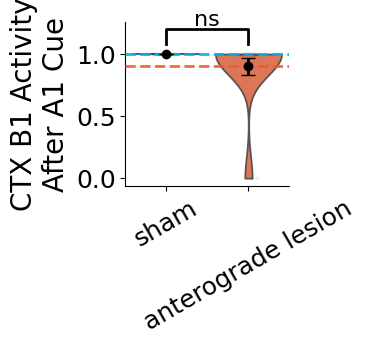

In [16]:
dist1 = (
    "sham",
    retrograde_summary_df[retrograde_summary_df["condition"] == "sham"]["target_ctx_mean"].tolist(),
)

dist2 = (
    "anterograde lesion",
    retrograde_summary_df[retrograde_summary_df["condition"] == "retrograde"]["target_ctx_mean"].tolist(),
)


blue = '#00AEEF'
red = '#F15A2A'

palette = {
    "sham": blue,
    "anterograde lesion": red,
}

compare_distributions_12(dist1, dist2, palette)
plt.ylabel("CTX B1 Activity\nAfter A1 Cue", fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks(fontsize=18)
plt.tight_layout()
sns.despine()


In [17]:
noise_sweep_params = {}
noise_sweep_params["num_seeds"] = 10
noise_sweep_params["num_cpu"] = 8
noise_sweep_params["num_swaps_ctx_values"] = range(10, 40)
noise_sweep_params["pair_index"] = None
noise_sweep_params["association_day_length"] = 25
noise_sweep_params["ctx_pattern_complete_iterations"] = 10
noise_sweep_params["assembly_size"] = 10

noise_sweep_network = network
noise_sweep_latent_specs = latent_specs
noise_sweep_input_params = input_params
noise_sweep_recording_parameters = recording_parameters


def run_retrograde_association_noise_point(seed, num_swaps_ctx):
    retrograde_test = run_retrograde_association_test(
        noise_sweep_network,
        noise_sweep_latent_specs,
        noise_sweep_input_params,
        noise_sweep_recording_parameters,
        seed=seed,
        pair_index=noise_sweep_params["pair_index"],
        association_day_length=noise_sweep_params["association_day_length"],
        num_swaps_ctx=num_swaps_ctx,
        ctx_pattern_complete_iterations=noise_sweep_params["ctx_pattern_complete_iterations"],
        assembly_size=noise_sweep_params["assembly_size"],
    )

    return {
        "seed": seed,
        "pair_index": retrograde_test["pair_index"],
        "num_swaps_ctx": num_swaps_ctx,
        "sham_target_ctx_mean": retrograde_test["test_results"]["sham"]["target_ctx_mean"],
        "retrograde_target_ctx_mean": retrograde_test["test_results"]["retrograde"]["target_ctx_mean"],
    }


experiment_params = [
    (seed, num_swaps_ctx)
    for num_swaps_ctx in noise_sweep_params["num_swaps_ctx_values"]
    for seed in range(noise_sweep_params["num_seeds"])
]

pool = multiprocessing.Pool(processes=noise_sweep_params["num_cpu"])
noise_sweep_results = pool.starmap(run_retrograde_association_noise_point, experiment_params)
pool.close()
pool.join()

,seed,pair_index,num_swaps_ctx,sham_target_ctx_mean,retrograde_target_ctx_mean
0,0,4,10,1.0,1.0
1,1,0,10,1.0,1.0
2,2,3,10,1.0,1.0
3,3,1,10,1.0,1.0
4,4,0,10,1.0,1.0
...,...,...,...,...,...
295,5,1,39,0.0,0.0
296,6,0,39,1.0,0.0
297,7,0,39,0.0,0.0
298,8,3,39,0.0,0.0


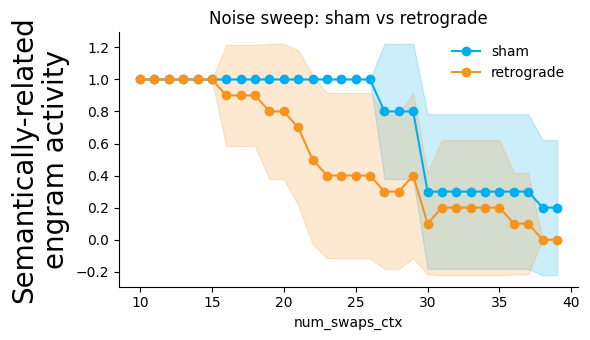

In [18]:
noise_sweep_df = pd.DataFrame(noise_sweep_results)
display(noise_sweep_df)

noise_summary = (
    noise_sweep_df.groupby("num_swaps_ctx")
    .agg(
        sham_target_ctx_mean_mean=("sham_target_ctx_mean", "mean"),
        sham_target_ctx_mean_std=("sham_target_ctx_mean", "std"),
        retrograde_target_ctx_mean_mean=("retrograde_target_ctx_mean", "mean"),
        retrograde_target_ctx_mean_std=("retrograde_target_ctx_mean", "std"),
    )
    .reset_index()
)

fig, ax = plt.subplots(1, 1, figsize=(6, 3.5))

x = noise_summary["num_swaps_ctx"].values
sham_mean = noise_summary["sham_target_ctx_mean_mean"].values
sham_std = noise_summary["sham_target_ctx_mean_std"].fillna(0).values
retrograde_mean = noise_summary["retrograde_target_ctx_mean_mean"].values
retrograde_std = noise_summary["retrograde_target_ctx_mean_std"].fillna(0).values

ax.plot(x, sham_mean, marker='o', color=blue, label='sham')
ax.fill_between(x, sham_mean - sham_std, sham_mean + sham_std, color=blue, alpha=0.2)

ax.plot(x, retrograde_mean, marker='o', color=orange, label='retrograde')
ax.fill_between(x, retrograde_mean - retrograde_std, retrograde_mean + retrograde_std, color=orange, alpha=0.2)

ax.set_xlabel('num_swaps_ctx')
ax.set_ylabel('Semantically-related\nengram activity', fontsize=20)
ax.set_title('Noise sweep: sham vs retrograde')
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()

plt.savefig('Figures_SVG/7g.svg', dpi=300, transparent=True)
